In [2]:
import pandas as pd

df= pd.read_excel("C:/Users/dell/Desktop/heart-failure-prediction-groupe21/data/heart_failure_clinical_records_dataset.xls")

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
# Structure du DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
# Résumé statistique des colonnes numériques
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [5]:
# Compter les valeurs manquantes par colonne
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [6]:
# Compter les occurrences de DEATH_EVENT
print(df['DEATH_EVENT'].value_counts())
# En pourcentage
print(df['DEATH_EVENT'].value_counts(normalize=True))

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64


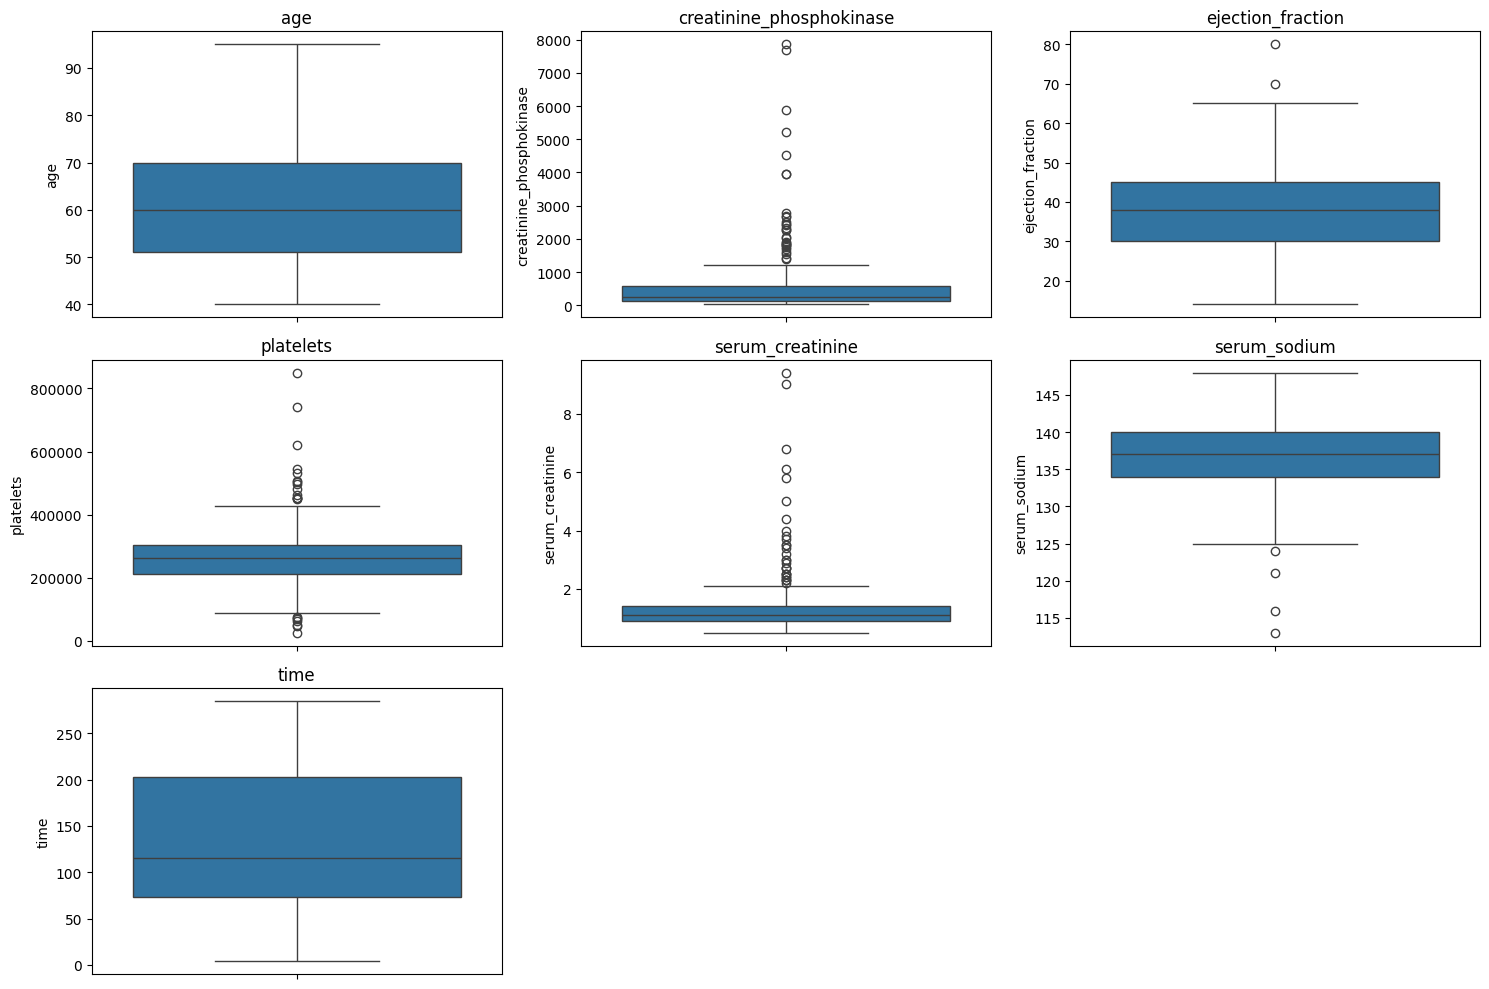

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des colonnes numériques
numeric_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 
                'platelets', 'serum_creatinine', 'serum_sodium', 'time']

# Tracer des boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

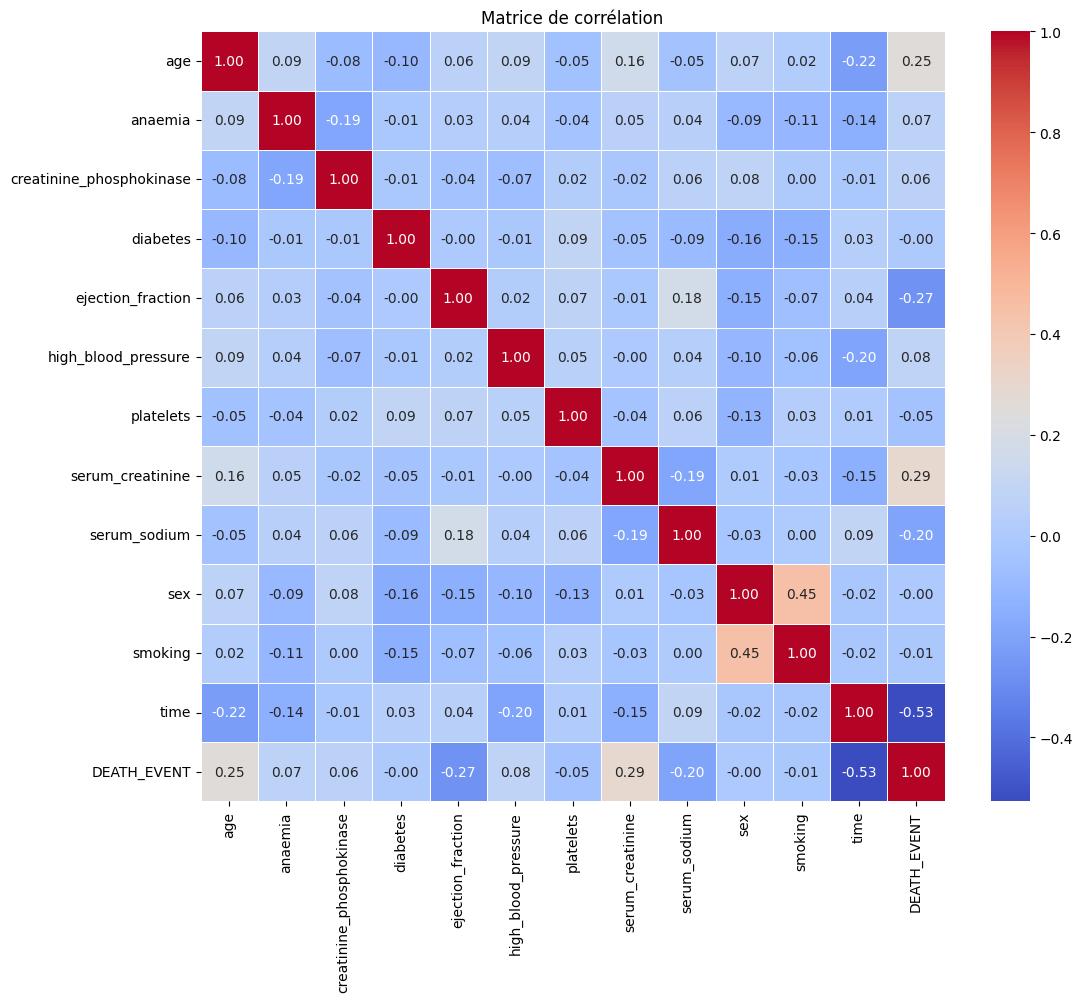

In [8]:
# Calculer la matrice de corrélation
corr = df.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation')
plt.show()

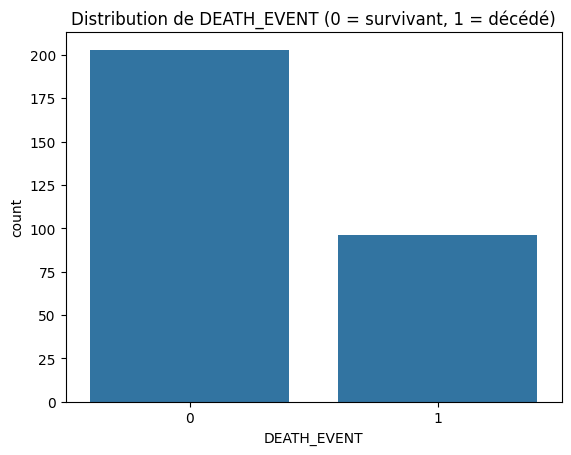

In [9]:
sns.countplot(x='DEATH_EVENT', data=df)
plt.title('Distribution de DEATH_EVENT (0 = survivant, 1 = décédé)')
plt.show()

In [1]:
import sys
sys.path.append('C:/Users/pc/Documents/GitHub/heart-failure-prediction-groupe21/src')
from data_processing import load_data, optimize_memory

# Charger les données
df = load_data('C:/Users/pc/Documents/GitHub/heart-failure-prediction-groupe21/data/heart_failure_clinical_records_dataset.xls')

# Mémoire AVANT
before = df.memory_usage(deep=True).sum()
print(f"Mémoire AVANT : {before} bytes")

# Optimiser
df_optimized = optimize_memory(df)

# Mémoire APRÈS
after = df_optimized.memory_usage(deep=True).sum()
print(f"Mémoire APRÈS : {after} bytes")
print(f"Réduction : {round((before - after) / before * 100, 1)}%")


Mémoire AVANT : 31224 bytes
Mémoire APRÈS : 15676 bytes
Réduction : 49.8%
